#### Food Delivery Order Analysis Dashboard

##### Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Lead DataSheet

df = pd.read_csv('food_delivery_data.csv')

print(df.head())

# Basic Information

print(df.columns)

print(df.dtypes)

print(df.shape)

   Order_ID  Gender  Age       City Cuisine_Type  Items_Ordered  \
0         1    Male   35       Pune      Italian              5   
1         2    Male   22  Bangalore      Chinese              2   
2         3    Male   43      Delhi      Mexican              4   
3         4  Female   47     Mumbai      Mexican              4   
4         5    Male   29      Delhi      Chinese              5   

   Price_Per_Item  Order_Date  Total_Amount  
0             107  2025-07-11           535  
1             341  2025-06-02           682  
2             243  2025-07-29           972  
3             228  2025-07-16           912  
4             310  2025-06-16          1550  
Index(['Order_ID', 'Gender', 'Age', 'City', 'Cuisine_Type', 'Items_Ordered',
       'Price_Per_Item', 'Order_Date', 'Total_Amount'],
      dtype='str')
Order_ID          int64
Gender              str
Age               int64
City                str
Cuisine_Type        str
Items_Ordered     int64
Price_Per_Item    int64
O

In [7]:
#convert order_date to datetime

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print(df.dtypes)

Order_ID                   int64
Gender                       str
Age                        int64
City                         str
Cuisine_Type                 str
Items_Ordered              int64
Price_Per_Item             int64
Order_Date        datetime64[us]
Total_Amount               int64
dtype: object


In [8]:
# Numpy Calculation

# Average total amount

average_total = np.mean(df['Total_Amount'])

# Average Item Ordered

average_ordered = np.mean(df['Items_Ordered'])

# Highest Order amount

maximum_order = np.max(df['Total_Amount'])

# Lowest Order amount

minimum_order = np.min(df['Total_Amount'])

print("Numpy Calculation")

print("Average Total Amount :" , average_total)

print("Average items ordered : " , average_ordered)

print("Highest Order amount :" , maximum_order)

print("Lowest Order amount :" , minimum_order)

Numpy Calculation
Average Total Amount : 757.1555555555556
Average items ordered :  3.111111111111111
Highest Order amount : 1975
Lowest Order amount : 104


In [16]:
# Group Total Sales by order

Gender_sales = df.groupby("Gender")['Items_Ordered'].sum()

print(Gender_sales)

city_sales = df.groupby("City")['Items_Ordered'].sum()

print(city_sales)


cuisine_sales = df.groupby("Cuisine_Type")['Items_Ordered'].sum()

print(cuisine_sales)

weekly_orders = df.groupby(df['Order_Date'].dt.to_period('W')).size()

print(weekly_orders)

Gender
Female    248
Male      312
Name: Items_Ordered, dtype: int64
City
Bangalore    122
Delhi        127
Mumbai       144
Pune          83
Surat         84
Name: Items_Ordered, dtype: int64
Cuisine_Type
Chinese      106
Fast Food    108
Indian       128
Italian       75
Mexican      143
Name: Items_Ordered, dtype: int64
Order_Date
2025-05-26/2025-06-01     3
2025-06-02/2025-06-08    35
2025-06-09/2025-06-15    17
2025-06-16/2025-06-22    21
2025-06-23/2025-06-29    24
2025-06-30/2025-07-06    18
2025-07-07/2025-07-13    13
2025-07-14/2025-07-20    24
2025-07-21/2025-07-27    14
2025-07-28/2025-08-03    11
Freq: W-SUN, dtype: int64


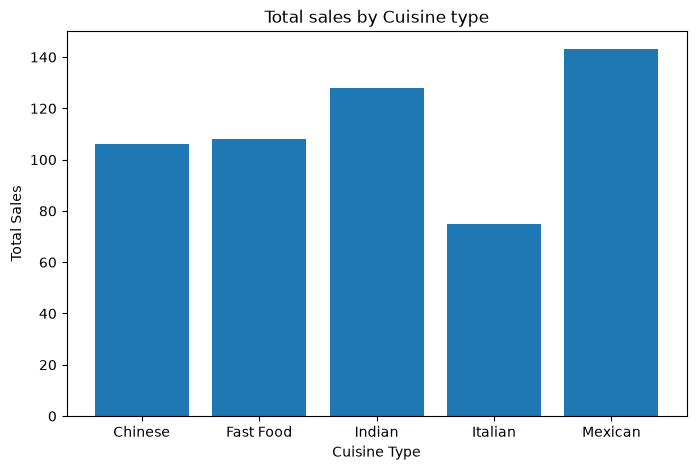

In [17]:
# Visulization

# Bar chart - total sales by cuisine type

plt.figure(figsize=(8 , 5))

plt.bar(
  cuisine_sales.index,
  cuisine_sales.values
)

plt.title("Total sales by Cuisine type")

plt.xlabel("Cuisine Type")
plt.ylabel("Total Sales")

plt.show()

City
Mumbai       47
Bangalore    41
Delhi        38
Pune         28
Surat        26
Name: count, dtype: int64


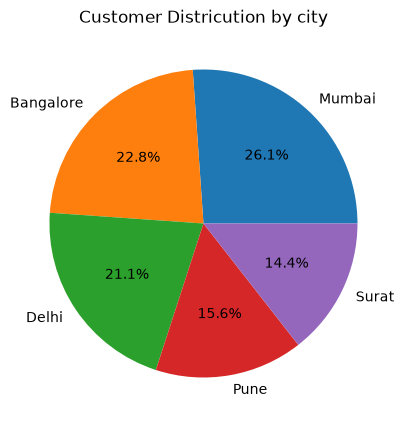

In [19]:
city_customers = df['City'].value_counts()

print(city_customers)

plt.figure(figsize=(8 , 5))

plt.pie(
  city_customers.values,
  labels=city_customers.index,
  autopct="%1.1f%%"
)

plt.title("Customer Districution by city")

plt.show()


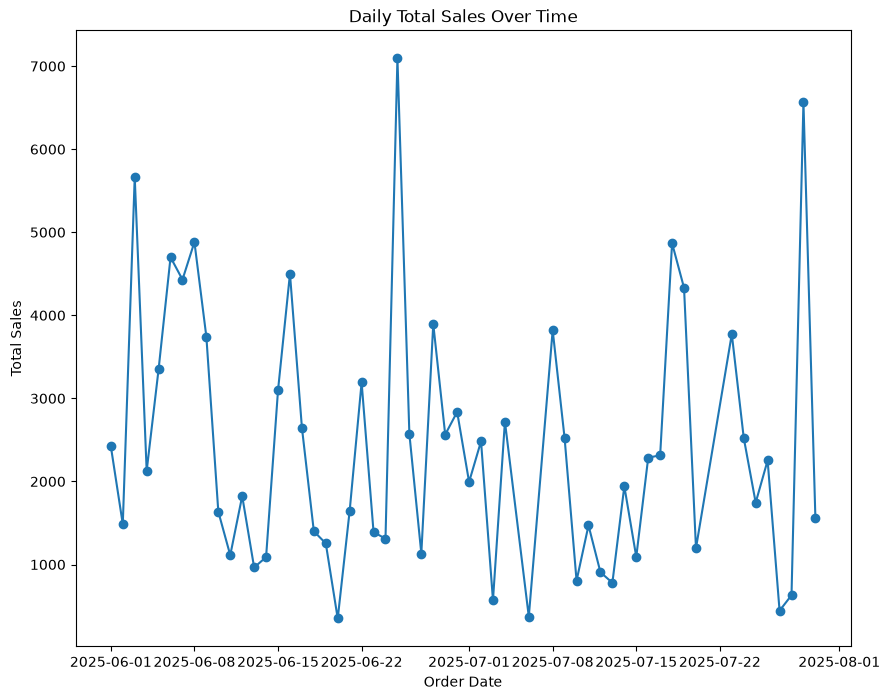

In [20]:
daily_sales = df.groupby("Order_Date")["Total_Amount"].sum()

plt.figure(figsize=(10 , 8))

plt.plot(
  daily_sales.index,
  daily_sales.values,
  marker="o"
)

plt.title("Daily Total Sales Over Time")

plt.xlabel("Order Date")

plt.ylabel("Total Sales")

plt.show()



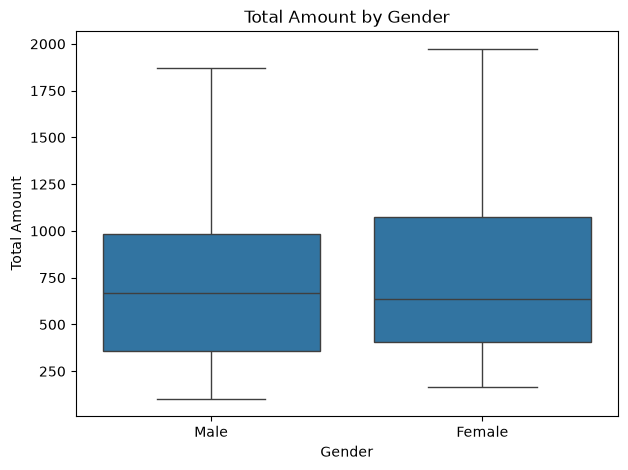

In [25]:
# Seaborn Box Plot

plt.figure(figsize=(7 , 5))

sns.boxplot(
  x="Gender",
  y = "Total_Amount",
  data = df,
)

plt.title("Total Amount by Gender")

plt.xlabel("Gender")
plt.ylabel("Total Amount")

plt.show()

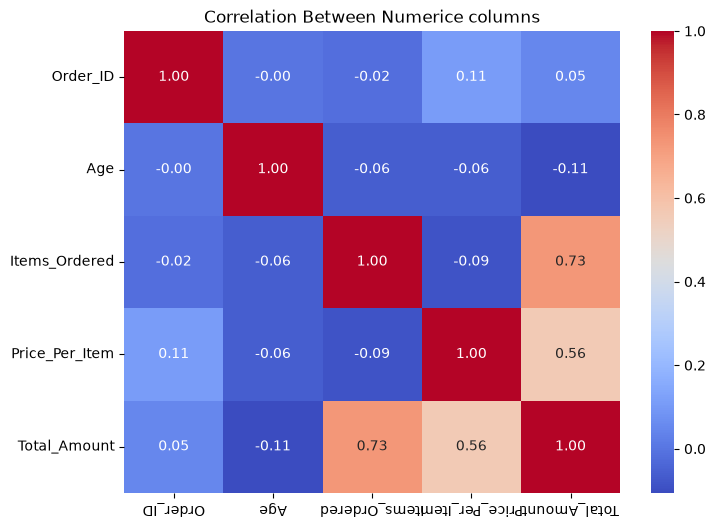

In [34]:
# Heatmap in seaborn

numeric_columns = df.select_dtypes(include=np.number)

correlation = numeric_columns.corr()


plt.figure(figsize=(8 , 6))

sns.heatmap(
  correlation,
  annot=True,
  cmap="coolwarm",
  fmt=".2f"
)

plt.xticks(rotation=180)

plt.title("Correlation Between Numerice columns")

plt.show()